# CMAPSS Preprocessing Pipeline

This notebook preprocesses the CMAPSS datasets into numpy arrays ready for feeding into a Vanilla LSTM model.

## Pipeline Overview
1. Load raw data (train, test, RUL ground truth)
2. Drop constant sensors (std ≈ 0) — data-driven, no hard-coded sensor list
3. Fit MinMax scaler on **train only**, transform both train and test
4. Compute piecewise-linear RUL labels for training set
5. Build sliding window sequences for train (`X_train`, `y_train`)
6. Build final-window sequences for test (`X_test`, `y_test`)
7. Save all arrays to disk as `.npy` files

### References
- Piecewise linear RUL: standard in the CMAPSS literature, `early_rul=125`
- Window size `w=30`: used in Li et al. (2018) DCNN and Zheng et al. (2017) LSTM
- Scaler fit on train only: avoids data leakage from test distribution

## 0. Configuration

All tunable parameters live here. Change these and re-run the notebook to regenerate arrays.

In [13]:
# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR     = 'CMAPSSData/'          # path to raw .txt files
OUTPUT_DIR   = 'preprocessed/'        # where .npy files will be saved

WINDOW_SIZE  = 30                     # sequence length fed to the LSTM. 30 for FD001 and FD003 but 20 for FD002 and FD004 
EARLY_RUL    = 125                    # piecewise-linear RUL cap (cycles)
SCALE_RANGE  = (0, 1)                 # MinMax output range
STD_THRESHOLD = 1e-3                  # sensors with std < this are dropped

# ──────────────────────────────────────────────────────────────────────────────

## 1. Imports & Setup

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Column schema for all CMAPSS files
INDEX_COLS   = ['unit_nr', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS  = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"Processing datasets")
print(f"Window size (for FD001 and FD003): {WINDOW_SIZE}\n Window size (for FD002 and FD004): 20\n Early RUL cap: {EARLY_RUL}")

Output directory: c:\Users\flopp\OneDrive - Aarhus universitet\Aarhus Universitet\Bachelor Project\preprocessed
Processing datasets
Window size (for FD001 and FD003): 30
 Window size (for FD002 and FD004): 20
 Early RUL cap: 125


## 2. Helper Functions

In [15]:
def load_cmapss(data_dir, dataset):
    """
    Load train, test, and RUL files for a given CMAPSS dataset (e.g. 'FD001').
    Returns three DataFrames: train_df, test_df, rul_series.
    """
    def read_txt(fname):
        path = os.path.join(data_dir, fname)
        return pd.read_csv(path, sep=r'\s+', header=None, engine='python')

    train_df = read_txt(f'train_{dataset}.txt')
    test_df  = read_txt(f'test_{dataset}.txt')
    rul_df   = read_txt(f'RUL_{dataset}.txt')

    train_df.columns = ALL_COLS
    test_df.columns  = ALL_COLS
    rul_df.columns   = ['RUL']

    return train_df, test_df, rul_df['RUL']


def drop_constant_sensors(train_df, test_df, threshold=STD_THRESHOLD):
    """
    Drop sensor columns whose standard deviation in the TRAINING set is below
    `threshold`. Settings are also evaluated and dropped if constant.
    Returns filtered DataFrames and the list of dropped column names.
    """
    feature_cols = SETTING_COLS + SENSOR_COLS
    stds = train_df[feature_cols].std()
    drop_cols = stds[stds < threshold].index.tolist()

    train_out = train_df.drop(columns=drop_cols)
    test_out  = test_df.drop(columns=drop_cols)

    kept = [c for c in feature_cols if c not in drop_cols]
    return train_out, test_out, kept, drop_cols


def add_piecewise_rul(train_df, early_rul=EARLY_RUL):
    """
    Compute piecewise-linear RUL labels for the training set.
    Each engine's RUL is capped at `early_rul` at the start, then decreases
    linearly to 0 at the last observed cycle.

    This reflects the assumption that early in an engine's life, degradation
    is not yet informative — a standard choice in the CMAPSS literature (papers).
    """
    max_cycles = train_df.groupby('unit_nr')['time_cycles'].max()

    def rul_for_engine(group):
        unit = group['unit_nr'].iloc[0]
        max_c = max_cycles[unit]
        linear_rul = max_c - group['time_cycles']          # counts down to 0
        group = group.copy()
        group['RUL'] = linear_rul.clip(upper=early_rul)    # cap at early_rul
        return group

    return train_df.groupby('unit_nr', group_keys=False).apply(rul_for_engine)


def fit_scaler(train_df, feature_cols):
    """
    Fit a MinMaxScaler on the training set feature columns only.
    IMPORTANT: The scaler must never see test data during fitting —
    this would constitute data leakage.
    """
    scaler = MinMaxScaler(feature_range=SCALE_RANGE)
    scaler.fit(train_df[feature_cols])
    return scaler


def apply_scaler(df, scaler, feature_cols):
    """Apply a pre-fitted scaler to a DataFrame in-place (returns copy)."""
    df = df.copy()
    df[feature_cols] = scaler.transform(df[feature_cols])
    return df


def build_train_windows(train_df, feature_cols, window_size=WINDOW_SIZE):
    """
    Build sliding window sequences from training data.

    For each engine and each valid end-position t (where t >= window_size),
    we extract the window [t-window_size : t] of sensor readings as one sample,
    and the RUL at position t as the label.

    Output shapes:
        X: (n_samples, window_size, n_features)
        y: (n_samples,)
    """
    X_list, y_list = [], []

    for unit, group in train_df.groupby('unit_nr'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        n      = len(data)

        for end in range(window_size, n + 1):          # end is exclusive
            X_list.append(data[end - window_size : end])
            y_list.append(labels[end - 1])             # RUL at last step of window

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def build_test_windows(test_df, rul_series, feature_cols, window_size=WINDOW_SIZE):
    """
    Build test sequences — one per engine, using the LAST `window_size` cycles.

    This matches the CMAPSS evaluation protocol: RUL_FD00X.txt provides the
    ground-truth RUL at the last observed cycle for each engine. If an engine
    has fewer than `window_size` cycles, we left-pad with zeros.

    Output shapes:
        X: (n_engines, window_size, n_features)
        y: (n_engines,)
    """
    X_list, y_list = [], []

    for unit, group in test_df.groupby('unit_nr'):
        data = group[feature_cols].values
        n    = len(data)

        if n >= window_size:
            window = data[-window_size:]               # last window_size rows
        else:
            # Left-pad with zeros if engine history is shorter than window
            pad    = np.zeros((window_size - n, len(feature_cols)), dtype=np.float32)
            window = np.vstack([pad, data])

        X_list.append(window)
        y_list.append(rul_series.iloc[unit - 1])       # unit_nr is 1-indexed

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

## 3. Main Preprocessing Loop

Iterates over FD001 and FD003, applies the full pipeline, and saves results.

In [16]:
summary = {}   # will hold a small report per dataset

DATASETS = ['FD001', 'FD003']     # subsets to process 

for ds in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Processing {ds}")
    print(f"{'='*60}")

    # ── 3.1 Load ──────────────────────────────────────────────────────────────
    train_df, test_df, rul_series = load_cmapss(DATA_DIR, ds)
    print(f"  Train shape: {train_df.shape} | Test shape: {test_df.shape}")
    print(f"  Engines (train): {train_df['unit_nr'].nunique()} | "
          f"Engines (test): {test_df['unit_nr'].nunique()}")

    # ── 3.2 Drop constant sensors ─────────────────────────────────────────────
    train_df, test_df, feature_cols, dropped = drop_constant_sensors(train_df, test_df)
    print(f"  Dropped {len(dropped)} constant columns: {dropped}")
    print(f"  Retained features ({len(feature_cols)}): {feature_cols}")

    # ── 3.3 Add piecewise-linear RUL to training set ──────────────────────────
    train_df = add_piecewise_rul(train_df, early_rul=EARLY_RUL)
    print(f"  RUL range in training set: "
          f"[{train_df['RUL'].min():.0f}, {train_df['RUL'].max():.0f}]")

    # ── 3.4 Scale: fit on train, transform both ───────────────────────────────
    scaler    = fit_scaler(train_df, feature_cols)
    train_df  = apply_scaler(train_df, scaler, feature_cols)
    test_df   = apply_scaler(test_df,  scaler, feature_cols)
    print(f"  Scaling range after transform — "
          f"train min: {train_df[feature_cols].values.min():.3f}, "
          f"max: {train_df[feature_cols].values.max():.3f}")

    # ── 3.5 Build windows ─────────────────────────────────────────────────────
    X_train, y_train = build_train_windows(train_df, feature_cols, WINDOW_SIZE)
    X_test,  y_test  = build_test_windows(test_df, rul_series, feature_cols, WINDOW_SIZE)

    print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
    print(f"  X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

    # ── 3.6 Save ──────────────────────────────────────────────────────────────
    prefix = os.path.join(OUTPUT_DIR, ds)
    np.save(f'{prefix}_X_train.npy', X_train)
    np.save(f'{prefix}_y_train.npy', y_train)
    np.save(f'{prefix}_X_test.npy',  X_test)
    np.save(f'{prefix}_y_test.npy',  y_test)
    # Also save the feature column names for reference in the LSTM notebook
    np.save(f'{prefix}_feature_cols.npy', np.array(feature_cols))

    print(f"  Saved to: {prefix}_{{X,y}}_{{train,test}}.npy")

    summary[ds] = {
        'n_features':       len(feature_cols),
        'dropped':          dropped,
        'train_samples':    X_train.shape[0],
        'test_engines':     X_test.shape[0],
        'window_size':      WINDOW_SIZE,
        'early_rul':        EARLY_RUL,
    }

print("\n✓ All datasets preprocessed.")


  Processing FD001
  Train shape: (20631, 26) | Test shape: (13096, 26)
  Engines (train): 100 | Engines (test): 100
  Dropped 8 constant columns: ['setting_2', 'setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
  Retained features (16): ['setting_1', 'T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']


C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\4146767992.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return train_df.groupby('unit_nr', group_keys=False).apply(rul_for_engine)


  RUL range in training set: [0, 125]
  Scaling range after transform — train min: 0.000, max: 1.000
  X_train: (17731, 30, 16) | y_train: (17731,)
  X_test:  (100, 30, 16)  | y_test:  (100,)
  Saved to: preprocessed/FD001_{X,y}_{train,test}.npy

  Processing FD003
  Train shape: (24720, 26) | Test shape: (16596, 26)
  Engines (train): 100 | Engines (test): 100
  Dropped 7 constant columns: ['setting_2', 'setting_3', 'T2', 'P2', 'farB', 'Nf_dmd', 'PCNfR_dmd']
  Retained features (17): ['setting_1', 'T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']


C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\4146767992.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return train_df.groupby('unit_nr', group_keys=False).apply(rul_for_engine)


  RUL range in training set: [0, 125]
  Scaling range after transform — train min: 0.000, max: 1.000
  X_train: (21820, 30, 17) | y_train: (21820,)
  X_test:  (100, 30, 17)  | y_test:  (100,)
  Saved to: preprocessed/FD003_{X,y}_{train,test}.npy

✓ All datasets preprocessed.


## 4. Summary Report

In [17]:
print("\n── Preprocessing Summary ──────────────────────────────────────────")
for ds, info in summary.items():
    print(f"\n  {ds}")
    for k, v in info.items():
        print(f"    {k:<20}: {v}")


── Preprocessing Summary ──────────────────────────────────────────

  FD001
    n_features          : 16
    dropped             : ['setting_2', 'setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
    train_samples       : 17731
    test_engines        : 100
    window_size         : 30
    early_rul           : 125

  FD003
    n_features          : 17
    dropped             : ['setting_2', 'setting_3', 'T2', 'P2', 'farB', 'Nf_dmd', 'PCNfR_dmd']
    train_samples       : 21820
    test_engines        : 100
    window_size         : 30
    early_rul           : 125


## 5. Sanity Checks & Visualisations

Before handing off to the LSTM, it's good practice to visually confirm the RUL labeling
and that the windowed sequences look sensible.

In [18]:
# ── 5.1 Reload and inspect one dataset ────────────────────────────────────────
ds_inspect = DATASETS[0]

X_tr = np.load(os.path.join(OUTPUT_DIR, f'{ds_inspect}_X_train.npy'))
y_tr = np.load(os.path.join(OUTPUT_DIR, f'{ds_inspect}_y_train.npy'))
X_te = np.load(os.path.join(OUTPUT_DIR, f'{ds_inspect}_X_test.npy'))
y_te = np.load(os.path.join(OUTPUT_DIR, f'{ds_inspect}_y_test.npy'))

print(f"Loaded {ds_inspect}")
print(f"  X_train : {X_tr.shape}")
print(f"  y_train : {y_tr.shape}")
print(f"  X_test  : {X_te.shape}")
print(f"  y_test  : {y_te.shape}")
print(f"\n  y_train range : [{y_tr.min():.1f}, {y_tr.max():.1f}]")
print(f"  y_test  range : [{y_te.min():.1f}, {y_te.max():.1f}]")

Loaded FD001
  X_train : (17731, 30, 16)
  y_train : (17731,)
  X_test  : (100, 30, 16)
  y_test  : (100,)

  y_train range : [0.0, 125.0]
  y_test  range : [7.0, 145.0]


In [29]:
X_test[99].shape

(30, 17)

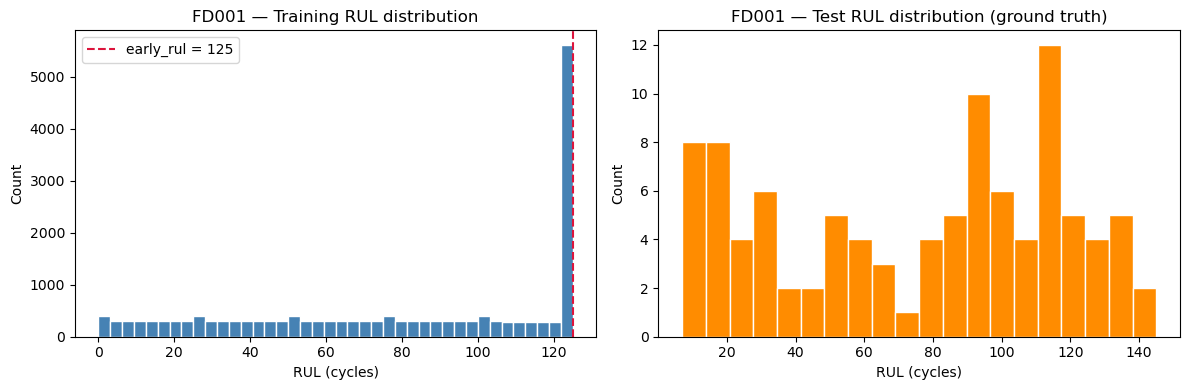

In [19]:
# ── 5.2 RUL label distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_tr, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(EARLY_RUL, color='crimson', linestyle='--',
                label=f'early_rul = {EARLY_RUL}')
axes[0].set_title(f'{ds_inspect} — Training RUL distribution')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(y_te, bins=20, color='darkorange', edgecolor='white')
axes[1].set_title(f'{ds_inspect} — Test RUL distribution (ground truth)')
axes[1].set_xlabel('RUL (cycles)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{ds_inspect}_rul_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

Sample [200] — RUL label: 125.0 cycles
Window shape: (30, 16)


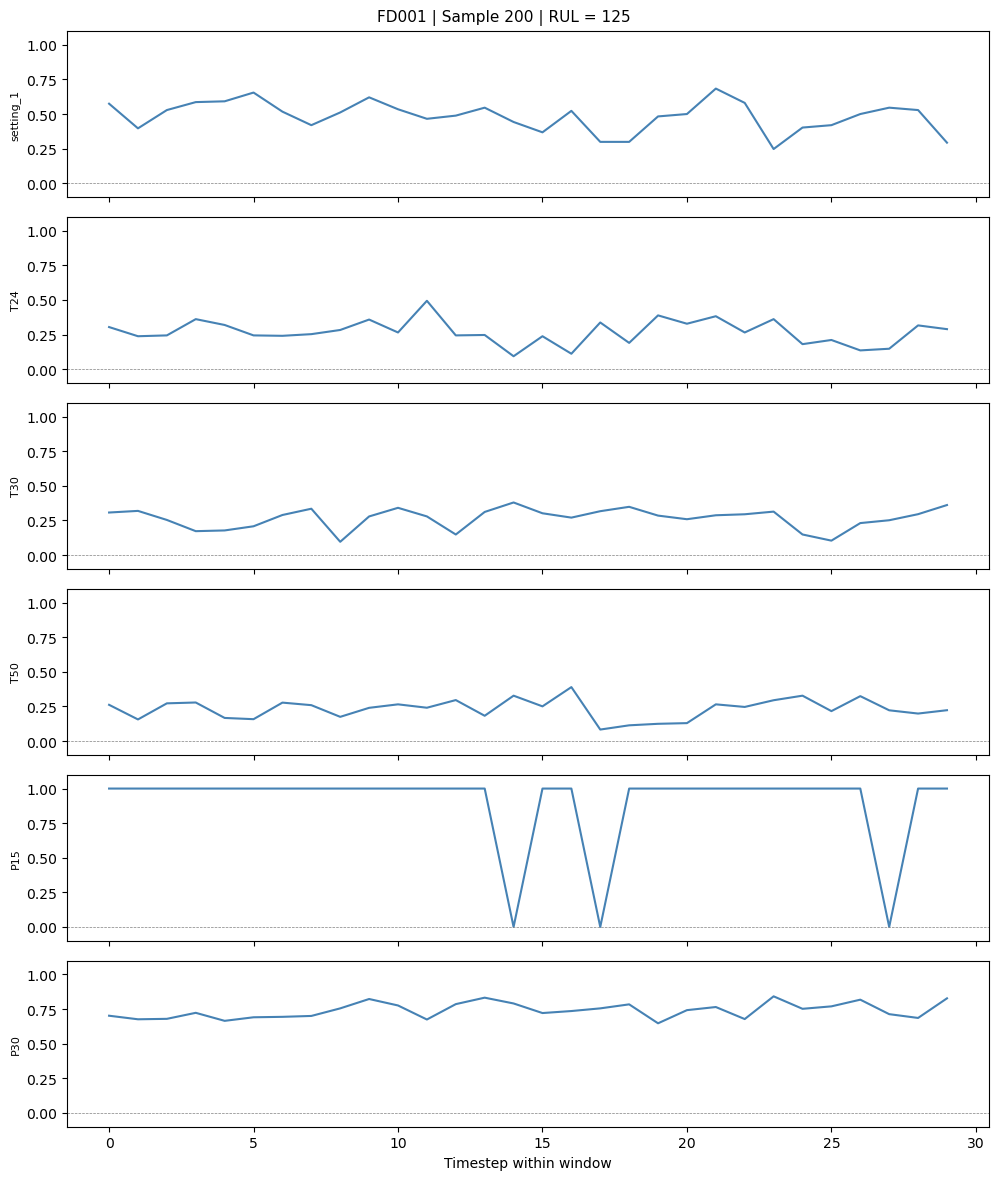

In [20]:
# ── 5.3 Inspect a single training window ─────────────────────────────────────
# Pick sample index 200 — should be mid-degradation
sample_idx  = 200
feat_cols   = list(np.load(os.path.join(OUTPUT_DIR, f'{ds_inspect}_feature_cols.npy')))
sample_win  = X_tr[sample_idx]                  # shape: (window_size, n_features)

print(f"Sample [{sample_idx}] — RUL label: {y_tr[sample_idx]:.1f} cycles")
print(f"Window shape: {sample_win.shape}")

# Plot first 6 features of this window
n_plot = min(6, sample_win.shape[1])
fig, axes = plt.subplots(n_plot, 1, figsize=(10, 2 * n_plot), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(sample_win[:, i], color='steelblue')
    ax.set_ylabel(feat_cols[i], fontsize=8)
    ax.set_ylim(-0.1, 1.1)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[-1].set_xlabel('Timestep within window')
fig.suptitle(f'{ds_inspect} | Sample {sample_idx} | RUL = {y_tr[sample_idx]:.0f}',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{ds_inspect}_sample_window.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Output File Manifest

The following files are now ready to be loaded in `Vanilla_LSTM.ipynb`:

```
preprocessed/
├── FD001_X_train.npy       # (n_samples, 30, n_features)
├── FD001_y_train.npy       # (n_samples,)
├── FD001_X_test.npy        # (100, 30, n_features)   — 100 test engines
├── FD001_y_test.npy        # (100,)
├── FD001_feature_cols.npy  # list of retained feature names
├── FD002_X_train.npy
├── FD002_y_train.npy
├── FD002_X_test.npy
├── FD002_y_test.npy
└── FD002_feature_cols.npy
```

Load in LSTM notebook with:
```python
X_train = np.load('preprocessed/FD001_X_train.npy')
y_train = np.load('preprocessed/FD001_y_train.npy')
X_test  = np.load('preprocessed/FD001_X_test.npy')
y_test  = np.load('preprocessed/FD001_y_test.npy')
```

---
## 7. FD002 & FD004 — Dual Normalisation Pipeline

FD002 and FD004 each contain **six distinct operational conditions** (combinations of altitude, throttle-resolver angle, and Mach number). Naively scaling all rows together conflates operating-point variation with true degradation signal. This section produces **two complementary preprocessed datasets** for each of those two sub-datasets:

| Variant | What gets scaled | Saved with suffix |
|---|---|---|
| **Unified** | Single Min-Max scaler fitted on the **entire** training split (settings included) | `_unified` |
| **Clustered** | One Min-Max scaler per KMeans cluster (k = 6), fitted on sensors only within that cluster | `_clustered` |

Both variants share the same window builder and RUL labelling logic from §§3-4.  
Model-comparison experiments should load the two versions and report scores side-by-side.

In [21]:
# ── Dual-Normalisation Config ─────────────────────────────────────────────────
# Datasets that require operational-condition-aware preprocessing
MULTI_OP_DATASETS = ['FD002', 'FD004']

# Number of distinct operating points (verified from domain knowledge + KMeans elbow)
N_CLUSTERS = 6

# Window sizes (FD002 / FD004 use w=20 as established above)
WINDOW_SIZE_MULTI = 20
# ─────────────────────────────────────────────────────────────────────────────

### 7.1 Shared Helper — cluster-aware scaler

A thin wrapper that trains one `MinMaxScaler` per KMeans cluster (fitted on sensors only,  
not on the operational-setting columns) and applies it to both train and test rows.

In [22]:
from sklearn.cluster import KMeans


def fit_clustered_scalers(train_df, feature_cols, op_cols=SETTING_COLS, n_clusters=N_CLUSTERS):
    """
    Fit one MinMaxScaler per KMeans cluster, where clusters are formed on the
    operational-setting columns only.

    Returns
    -------
    kmeans   : fitted KMeans model
    scalers  : dict  cluster_id -> fitted MinMaxScaler
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(train_df[op_cols].values)

    scalers = {}
    for cid in range(n_clusters):
        mask = cluster_labels == cid
        scaler = MinMaxScaler(feature_range=SCALE_RANGE)
        scaler.fit(train_df.loc[mask, feature_cols])
        scalers[cid] = scaler

    return kmeans, scalers


def apply_clustered_scalers(df, kmeans, scalers, feature_cols, op_cols=SETTING_COLS):
    """
    Assign each row to its cluster (predict from op settings) and apply the
    corresponding pre-fitted scaler.

    Returns a copy of *df* with `feature_cols` scaled in-place.
    """
    df = df.copy()
    cluster_labels = kmeans.predict(df[op_cols].values)
    df['_cluster'] = cluster_labels

    for cid, scaler in scalers.items():
        mask = df['_cluster'] == cid
        if mask.any():
            df.loc[mask, feature_cols] = scaler.transform(df.loc[mask, feature_cols])

    df.drop(columns=['_cluster'], inplace=True)
    return df

### 7.2 Main Loop — produce both variants

In [23]:
dual_summary = {}   # summary statistics for the report

for ds in MULTI_OP_DATASETS:
    print(f"\n{'='*60}")
    print(f"  Processing {ds}  (unified + clustered)")
    print(f"{'='*60}")

    # ── Load ──────────────────────────────────────────────────────────────────
    train_df, test_df, rul_series = load_cmapss(DATA_DIR, ds)
    print(f"  Train shape: {train_df.shape} | Test shape: {test_df.shape}")
    print(f"  Engines (train): {train_df['unit_nr'].nunique()} | "
          f"Engines (test): {test_df['unit_nr'].nunique()}")

    # ── Drop constant sensors ─────────────────────────────────────────────────
    train_df, test_df, feature_cols, dropped = drop_constant_sensors(train_df, test_df)
    print(f"  Dropped {len(dropped)} constant columns: {dropped}")
    print(f"  Retained features ({len(feature_cols)}): {feature_cols}")

    # ── Add piecewise-linear RUL to training set ──────────────────────────────
    train_df_rul = add_piecewise_rul(train_df, early_rul=EARLY_RUL)
    print(f"  RUL range: [{train_df_rul['RUL'].min():.0f}, {train_df_rul['RUL'].max():.0f}]")

    # ─────────────────────────────────────────────────────────────────────────
    #  VARIANT A — Unified normalisation
    # ─────────────────────────────────────────────────────────────────────────
    scaler_u = fit_scaler(train_df_rul, feature_cols)          # fit on full train
    train_u  = apply_scaler(train_df_rul, scaler_u, feature_cols)
    test_u   = apply_scaler(test_df,      scaler_u, feature_cols)

    X_train_u, y_train_u = build_train_windows(train_u, feature_cols, WINDOW_SIZE_MULTI)
    X_test_u,  y_test_u  = build_test_windows(test_u, rul_series, feature_cols, WINDOW_SIZE_MULTI)

    prefix_u = os.path.join(OUTPUT_DIR, f"{ds}_unified")
    np.save(f"{prefix_u}_X_train.npy",     X_train_u)
    np.save(f"{prefix_u}_y_train.npy",     y_train_u)
    np.save(f"{prefix_u}_X_test.npy",      X_test_u)
    np.save(f"{prefix_u}_y_test.npy",      y_test_u)
    np.save(f"{prefix_u}_feature_cols.npy", np.array(feature_cols))

    print(f"  [Unified]   X_train: {X_train_u.shape} | X_test: {X_test_u.shape}")
    print(f"  [Unified]   Saved  → {prefix_u}_{{X,y}}_{{train,test}}.npy")

    # ─────────────────────────────────────────────────────────────────────────
    #  VARIANT B — Clustered normalisation  (k = N_CLUSTERS)
    # ─────────────────────────────────────────────────────────────────────────
    # Note: clustering is always on the operational-setting columns;
    #       only sensor features are scaled (settings are *not* scaled).
    sensor_only_cols = [c for c in feature_cols if c not in SETTING_COLS]

    kmeans, scalers_c = fit_clustered_scalers(
        train_df_rul, sensor_only_cols, op_cols=SETTING_COLS, n_clusters=N_CLUSTERS
    )

    train_c = apply_clustered_scalers(train_df_rul, kmeans, scalers_c,
                                       sensor_only_cols, op_cols=SETTING_COLS)
    test_c  = apply_clustered_scalers(test_df,       kmeans, scalers_c,
                                       sensor_only_cols, op_cols=SETTING_COLS)

    # For windowing we use all retained feature_cols (settings included as context)
    X_train_c, y_train_c = build_train_windows(train_c, feature_cols, WINDOW_SIZE_MULTI)
    X_test_c,  y_test_c  = build_test_windows(test_c, rul_series, feature_cols, WINDOW_SIZE_MULTI)

    prefix_c = os.path.join(OUTPUT_DIR, f"{ds}_clustered")
    np.save(f"{prefix_c}_X_train.npy",     X_train_c)
    np.save(f"{prefix_c}_y_train.npy",     y_train_c)
    np.save(f"{prefix_c}_X_test.npy",      X_test_c)
    np.save(f"{prefix_c}_y_test.npy",      y_test_c)
    np.save(f"{prefix_c}_feature_cols.npy", np.array(feature_cols))

    print(f"  [Clustered] X_train: {X_train_c.shape} | X_test: {X_test_c.shape}")
    print(f"  [Clustered] Saved  → {prefix_c}_{{X,y}}_{{train,test}}.npy")

    dual_summary[ds] = {
        'n_features':         len(feature_cols),
        'sensor_features':    len(sensor_only_cols),
        'n_clusters':         N_CLUSTERS,
        'window_size':        WINDOW_SIZE_MULTI,
        'early_rul':          EARLY_RUL,
        'unified_train':      X_train_u.shape[0],
        'clustered_train':    X_train_c.shape[0],
        'test_engines':       X_test_u.shape[0],

    }

print("\n✓ Dual-normalisation preprocessing complete.")


  Processing FD002  (unified + clustered)
  Train shape: (53759, 26) | Test shape: (33991, 26)
  Engines (train): 260 | Engines (test): 259
  Dropped 0 constant columns: []
  Retained features (24): ['setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']


C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\4146767992.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return train_df.groupby('unit_nr', group_keys=False).apply(rul_for_engine)


  RUL range: [0, 125]
  [Unified]   X_train: (48819, 20, 24) | X_test: (259, 20, 24)
  [Unified]   Saved  → preprocessed/FD002_unified_{X,y}_{train,test}.npy


C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\1858554074.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.33333333 0.22222222 0.33333333 ... 0.77777778 0.77777778 0.77777778]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, feature_cols] = scaler.transform(df.loc[mask, feature_cols])
C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\1858554074.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.55555556 0.33333333 0.33333333 ... 0.55555556 0.44444444 0.44444444]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, feature_cols] = scaler.transform(df.loc[mask, feature_cols])


  [Clustered] X_train: (48819, 20, 24) | X_test: (259, 20, 24)
  [Clustered] Saved  → preprocessed/FD002_clustered_{X,y}_{train,test}.npy

  Processing FD004  (unified + clustered)
  Train shape: (61249, 26) | Test shape: (41214, 26)
  Engines (train): 249 | Engines (test): 248
  Dropped 0 constant columns: []
  Retained features (24): ['setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']


C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\4146767992.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return train_df.groupby('unit_nr', group_keys=False).apply(rul_for_engine)


  RUL range: [0, 125]
  [Unified]   X_train: (56518, 20, 24) | X_test: (248, 20, 24)
  [Unified]   Saved  → preprocessed/FD004_unified_{X,y}_{train,test}.npy


C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\1858554074.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.36363636 0.27272727 0.18181818 ... 0.72727273 0.63636364 0.63636364]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, feature_cols] = scaler.transform(df.loc[mask, feature_cols])
C:\Users\flopp\AppData\Local\Temp\ipykernel_38592\1858554074.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.18181818 0.18181818 0.18181818 ... 0.54545455 0.54545455 0.45454545]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, feature_cols] = scaler.transform(df.loc[mask, feature_cols])


  [Clustered] X_train: (56518, 20, 24) | X_test: (248, 20, 24)
  [Clustered] Saved  → preprocessed/FD004_clustered_{X,y}_{train,test}.npy

✓ Dual-normalisation preprocessing complete.


### 7.3 Summary

In [24]:
print("\n── Dual-Normalisation Summary ─────────────────────────────────────────")
for ds, info in dual_summary.items():
    print(f"\n  {ds}")
    for k, v in info.items():
        print(f"    {k:<25}: {v}")


── Dual-Normalisation Summary ─────────────────────────────────────────

  FD002
    n_features               : 24
    sensor_features          : 21
    n_clusters               : 6
    window_size              : 20
    early_rul                : 125
    unified_train            : 48819
    clustered_train          : 48819
    test_engines             : 259

  FD004
    n_features               : 24
    sensor_features          : 21
    n_clusters               : 6
    window_size              : 20
    early_rul                : 125
    unified_train            : 56518
    clustered_train          : 56518
    test_engines             : 248


### 7.4 Output File Manifest

```
preprocessed/
├── FD002_unified_X_train.npy       # global MinMax, all features
├── FD002_unified_y_train.npy
├── FD002_unified_X_test.npy
├── FD002_unified_y_test.npy
├── FD002_unified_feature_cols.npy
├── FD002_clustered_X_train.npy     # per-cluster MinMax on sensors only
├── FD002_clustered_y_train.npy
├── FD002_clustered_X_test.npy
├── FD002_clustered_y_test.npy
├── FD002_clustered_feature_cols.npy
├── FD004_unified_X_train.npy
...  (same pattern)
└── FD004_clustered_feature_cols.npy
```

**Loading in your model notebook:**
```python
# Unified
X_train = np.load('preprocessed/FD002_unified_X_train.npy')
y_train = np.load('preprocessed/FD002_unified_y_train.npy')

# Clustered
X_train = np.load('preprocessed/FD002_clustered_X_train.npy')
y_train = np.load('preprocessed/FD002_clustered_y_train.npy')
```